# KNN

## Imports

In [193]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier

In [138]:
df_train = pd.read_csv("dados/nba_treino.csv")
df_test = pd.read_csv("dados/nba_teste.csv")

target_knn = 'TARGET_5Yrs'

X_train = df_train.drop(columns=target_knn)
X_test = df_test.drop(columns=target_knn)
y_train = df_train[target_knn]
y_test = df_test[target_knn]

## Definições de função

In [209]:
def euclidian_distance(p1, p2):
    array1 = np.array(p1)
    array2 = np.array(p2)

    return np.sum((array1 - array2)**2)

def sort_by_distance(center, df, labels):
    dists_and_labels = [] 
    
    for i, point in enumerate(df.to_numpy()):
        dist = euclidian_distance(center, point)
        dists_and_labels.append((dist, labels[i])) # o primeiro elemento é a distância entre o ponto e center, o segundo é a label do ponto

    dists_and_labels.sort(key=lambda x: x[0])

    labels_sorted = pd.DataFrame([ l[1] for l in dists_and_labels ]) # só as labels, sem a distância

    return labels_sorted

def knn_point(X_train, y_train, point, k):
    labels_by_dist = sort_by_distance(point, X_train, y_train)
    neighbors = labels_by_dist[:k]

    neighbor_targets = neighbors.value_counts() # o número de ocorrências de cada classe em neighbors

    return neighbor_targets.nlargest(1).index[0][0] # a classe de maior ocorrência

def knn_dataset(X_train, y_train, X_test, k):
    start = time.time()

    predictions = X_test.apply(lambda x: knn_point(X_train, y_train, x, k), axis=1)

    end = time.time()
    time_elapsed = round(end-start, 2)
    
    print("KNN feito em", time_elapsed, "segundos!")

    return predictions

def plot_confusion_matrix(y_test, y_predicted_original, y_predicted_scikit):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,4))
                                   
    sns.heatmap(data=metrics.confusion_matrix(y_test, y_predicted_original), annot=True, ax=ax1)
    ax1.set(xlabel = "Valor Previsto",
        ylabel = "Valor Real",
        title = "Original")
    
    sns.heatmap(data=metrics.confusion_matrix(y_test, y_predicted_scikit), annot=True, ax=ax2)
    ax2.set(xlabel = "Valor Previsto",
        ylabel = "Valor Real",
        title = "Scikit")

    fig.suptitle("Matrizes de Confusão")
    plt.show()

def print_knn_scores(y_test, y_predicted_original, y_predicted_scikit):
    metrics_to_print = {
        "Acurácia": metrics.accuracy_score,
        "Precisão": metrics.precision_score,
        "Recall": metrics.recall_score,
        "F1": metrics.f1_score
    }

    for index, funct in metrics_to_print.items():
        score_original = round(funct(y_test, y_predicted_original), 2)
        score_scikit = round(funct(y_test, y_predicted_scikit), 2)

        print(f"{index}:", f"\tOriginal: {score_original}", f"\tScikit: {score_scikit}", sep="\n")

    plot_confusion_matrix(y_test, y_predicted_original, y_predicted_scikit)

## Previsão e estatísticas

-----------------------------
k atual: 2
-----------------------------

KNN feito em 3.86 segundos!
Acurácia:
	Original: 0.6
	Scikit: 0.55
Precisão:
	Original: 0.68
	Scikit: 0.74
Recall:
	Original: 0.68
	Scikit: 0.45
F1:
	Original: 0.68
	Scikit: 0.56


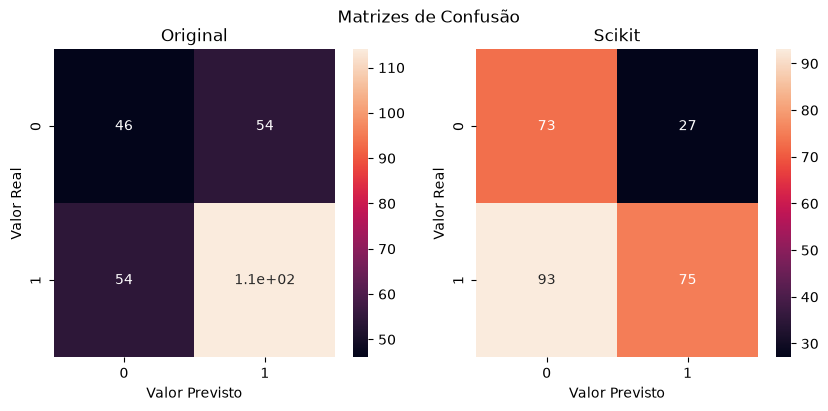

-----------------------------
k atual: 10
-----------------------------

KNN feito em 3.77 segundos!
Acurácia:
	Original: 0.64
	Scikit: 0.63
Precisão:
	Original: 0.71
	Scikit: 0.73
Recall:
	Original: 0.72
	Scikit: 0.66
F1:
	Original: 0.72
	Scikit: 0.69


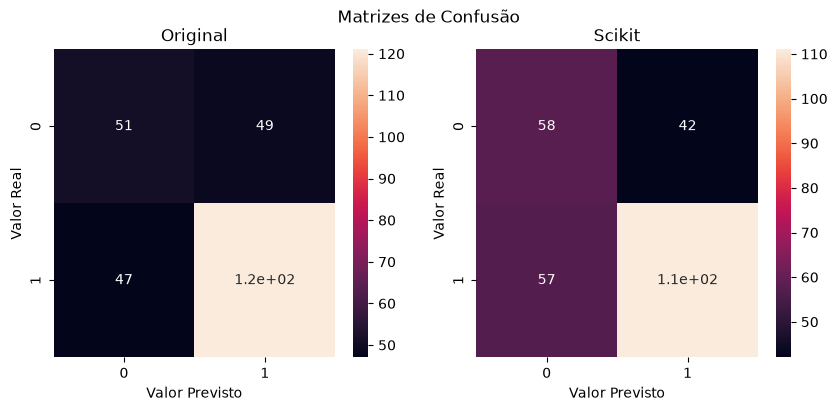

-----------------------------
k atual: 50
-----------------------------

KNN feito em 3.67 segundos!
Acurácia:
	Original: 0.68
	Scikit: 0.67
Precisão:
	Original: 0.74
	Scikit: 0.73
Recall:
	Original: 0.77
	Scikit: 0.75
F1:
	Original: 0.75
	Scikit: 0.74


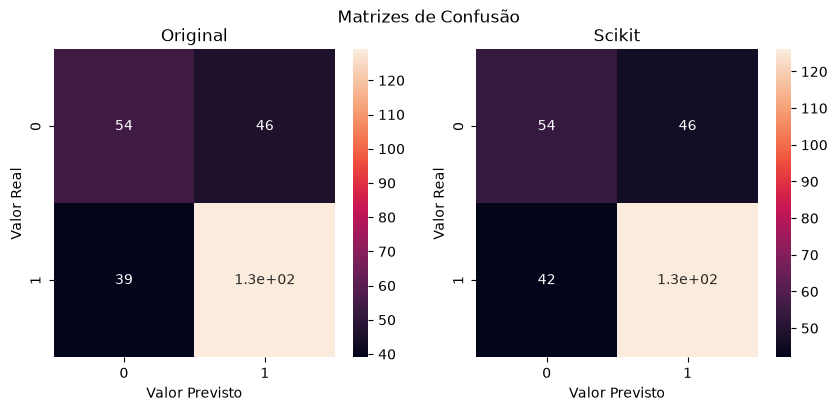

-----------------------------
k atual: 100
-----------------------------

KNN feito em 3.72 segundos!
Acurácia:
	Original: 0.69
	Scikit: 0.69
Precisão:
	Original: 0.74
	Scikit: 0.75
Recall:
	Original: 0.77
	Scikit: 0.76
F1:
	Original: 0.76
	Scikit: 0.76


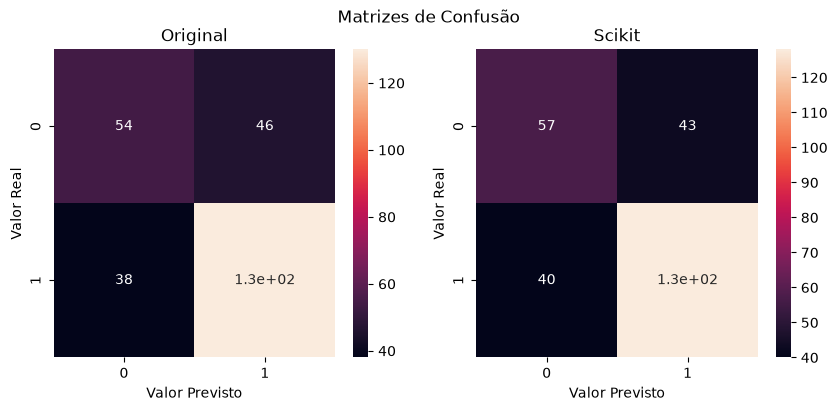

In [210]:
for k in [2, 10, 50, 100]:
    print(f"-----------------------------\nk atual: {k}\n-----------------------------\n")

    predictions_knn_original = knn_dataset(X_train, y_train, X_test, k)

    knn_scikit = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    predictions_knn_scikit = knn_scikit.predict(X_test)

    print_knn_scores(y_test, predictions_knn_original, predictions_knn_scikit)
